# Multi-Factor ANOVA (Two-Way ANOVA)

**Two-Way ANOVA** extends one-way ANOVA to two categorical factors, testing main effects and their interaction. The interaction term answers: *does the effect of Factor A depend on the level of Factor B?*

| Source | df | Tests |
|---|---|---|
| **Factor A** | a−1 | Main effect of A |
| **Factor B** | b−1 | Main effect of B |
| **A × B interaction** | (a−1)(b−1) | Does A effect depend on B? |
| **Error** | ab(n−1) | Within-cell variance |

Interaction plot: if lines are parallel → no interaction; if lines cross → interaction present.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
try:
    import statsmodels.formula.api as smf
    import pandas as pd
    HAS_SM = True
except ImportError:
    HAS_SM = False

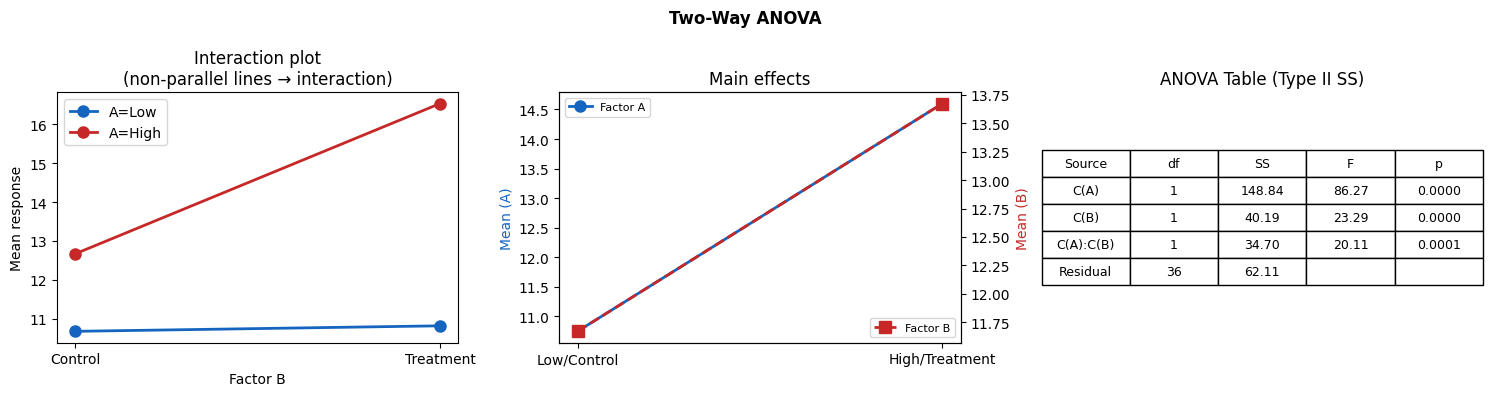

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.783
Model:                            OLS   Adj. R-squared:                  0.765
Method:                 Least Squares   F-statistic:                     43.23
Date:                Mon, 08 Jun 2026   Prob (F-statistic):           5.08e-12
Time:                        00:23:56   Log-Likelihood:                -65.559
No. Observations:                  40   AIC:                             139.1
Df Residuals:                      36   BIC:                             145.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         


In [2]:
np.random.seed(42)
# 2x2 factorial with replication (n=10 per cell)
a_levels = ['Low', 'High']
b_levels = ['Control', 'Treatment']
n_rep = 10

cell_means = {
    ('Low',  'Control'):   10.0,
    ('Low',  'Treatment'): 12.0,
    ('High', 'Control'):   13.0,
    ('High', 'Treatment'): 17.0,  # large interaction
}
sigma = 1.5

rows = []
for a in a_levels:
    for b in b_levels:
        mu = cell_means[(a, b)]
        for _ in range(n_rep):
            rows.append({'A': a, 'B': b, 'y': np.random.normal(mu, sigma)})

import pandas as pd
df = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Two-Way ANOVA', fontsize=12, fontweight='bold')

# Panel 1: interaction plot
cell_m = df.groupby(['A','B'])['y'].mean()
for a, color in zip(a_levels, ['#1565C0', '#C62828']):
    means = [cell_m[(a, b)] for b in b_levels]
    axes[0].plot(b_levels, means, 'o-', color=color, lw=2, ms=8, label=f'A={a}')
axes[0].set_title('Interaction plot\n(non-parallel lines → interaction)')
axes[0].set_xlabel('Factor B'); axes[0].set_ylabel('Mean response')
axes[0].legend()

# Panel 2: main effects
ax2a = axes[1]
means_a = df.groupby('A')['y'].mean()
means_b = df.groupby('B')['y'].mean()
x = [0, 1]
ax2a.plot(x, [means_a['Low'], means_a['High']], 'o-', color='#1565C0', lw=2, ms=8, label='Factor A')
ax2b = ax2a.twinx()
ax2b.plot(x, [means_b['Control'], means_b['Treatment']], 's--', color='#C62828', lw=2, ms=8, label='Factor B')
ax2a.set_xticks([0, 1]); ax2a.set_xticklabels(['Low/Control', 'High/Treatment'])
ax2a.set_title('Main effects'); ax2a.set_ylabel('Mean (A)', color='#1565C0')
ax2b.set_ylabel('Mean (B)', color='#C62828')
ax2a.legend(loc='upper left', fontsize=8); ax2b.legend(loc='lower right', fontsize=8)

# Panel 3: two-way ANOVA table via OLS
if HAS_SM:
    model = smf.ols('y ~ C(A) * C(B)', data=df).fit()
    from statsmodels.stats.anova import anova_lm
    tbl = anova_lm(model, typ=2)
    axes[2].axis('off')
    table_data = []
    for src, row in tbl.iterrows():
        table_data.append([str(src)[:18],
                           f'{row["df"]:.0f}',
                           f'{row["sum_sq"]:.2f}',
                           f'{row["F"]:.2f}' if not np.isnan(row['F']) else '',
                           f'{row["PR(>F)"]:.4f}' if not np.isnan(row['PR(>F)']) else ''])
    t = axes[2].table(cellText=table_data, colLabels=['Source','df','SS','F','p'],
                      loc='center', cellLoc='center')
    t.auto_set_font_size(False); t.set_fontsize(9); t.scale(1.1, 2.0)
    axes[2].set_title('ANOVA Table (Type II SS)')
else:
    axes[2].text(0.5, 0.5, 'statsmodels required', ha='center', va='center')
    axes[2].set_title('ANOVA Table')
    axes[2].axis('off')

plt.tight_layout(); plt.show()

if HAS_SM:
    print(model.summary().tables[0])


## Key Takeaways

| | |
|---|---|
| **Interaction first** | Always check interaction before interpreting main effects |
| **Significant interaction** | Main effects are misleading — describe simple effects instead |
| **Parallel interaction plot** | No interaction — main effects are interpretable independently |
| **Type I vs Type II SS** | Type II preferred for balanced and unbalanced designs |
| **Effect size** | Partial η² = SS_effect / (SS_effect + SS_error) |
| **Extension** | Three-way ANOVA, ANCOVA (continuous covariate), repeated measures |